# Neural Network Example 2

This notebook illustrates a more advanced neural network that will identify handwriting.

# MNIST Dataset

This notebook uses the MNIST dataset, which contains samples of handwriting in 28x28 images.

Image recognition problems frequently use Convolutional Neural Networks and other more advanced networks, however, due to the nature of the dataset (fixed size images, with fixed size features), we can process the MNIST dataset using a more simple neural network.

The code in the next cell will downlaod the files directly, 
The dataset can be downloaded here : https://www.kaggle.com/datasets/hojjatk/mnist-dataset/code

You should unzip the downloaded file into the same directory as this notebook.


In [4]:
import torch
from torchvision import datasets, transforms

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])
dataset1 = datasets.MNIST('data', train=True, download=True, transform=transform)
dataset2 = datasets.MNIST('data', train=False, transform=transform)
train_loader = torch.utils.data.DataLoader(dataset1, batch_size=64)
val_loader = torch.utils.data.DataLoader(dataset2)

We can view some images using `matplotlib.imshow()`

Label : 7


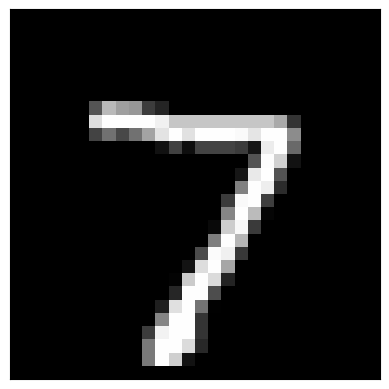

Label : 2


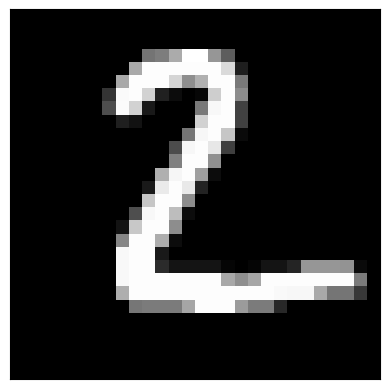

Label : 1


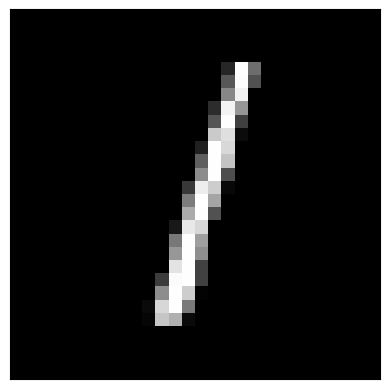

Label : 0


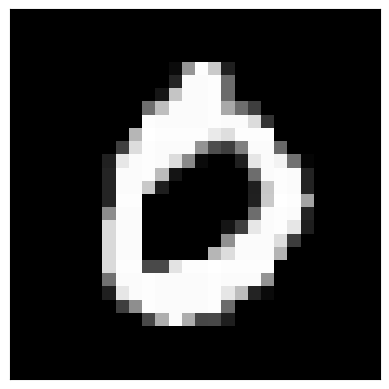

Label : 4


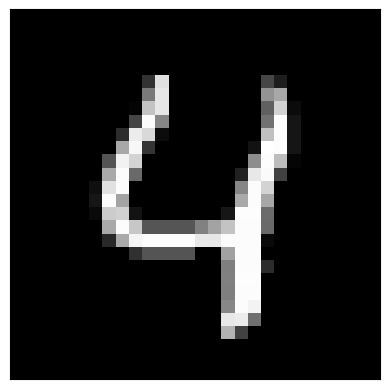

Label : 1


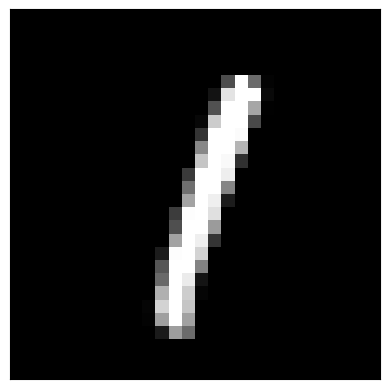

Label : 4


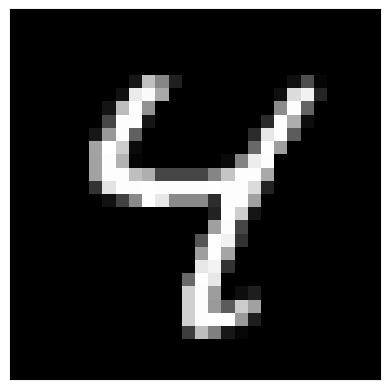

Label : 9


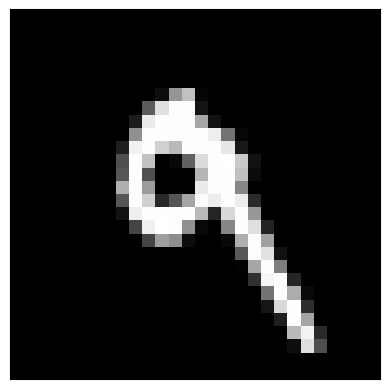

Label : 5


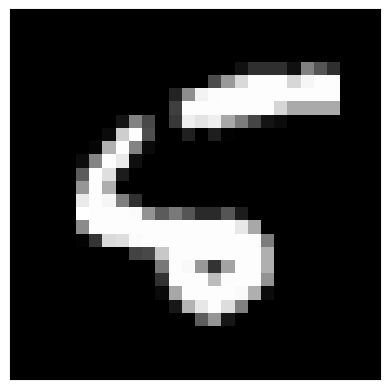

Label : 9


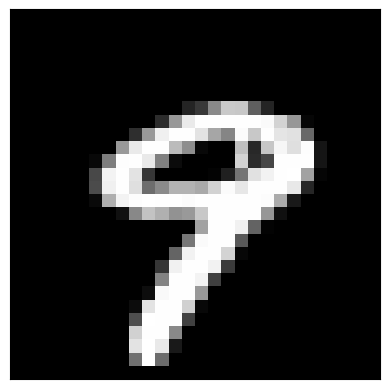

Label : 0


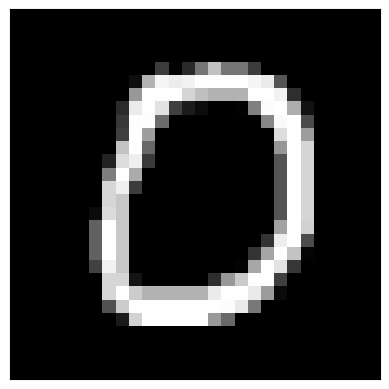

Label : 6


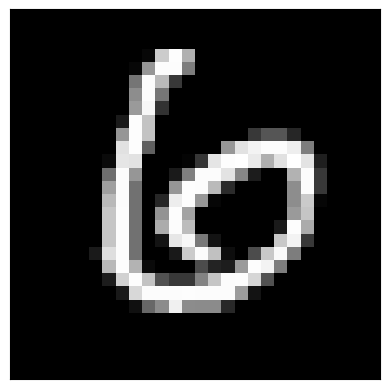

Label : 9


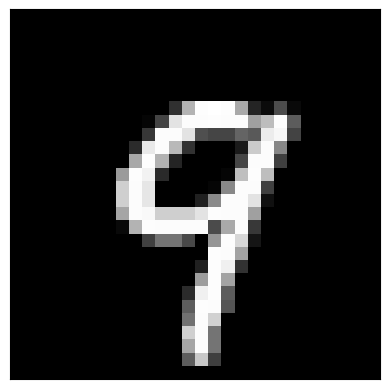

Label : 0


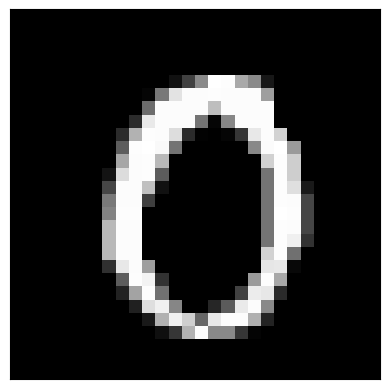

Label : 1


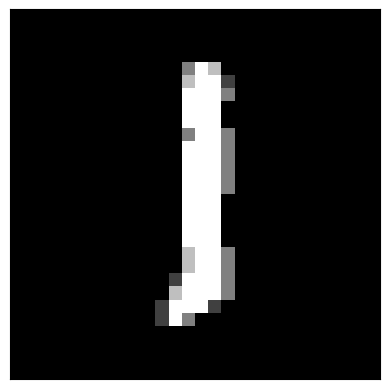

Label : 5


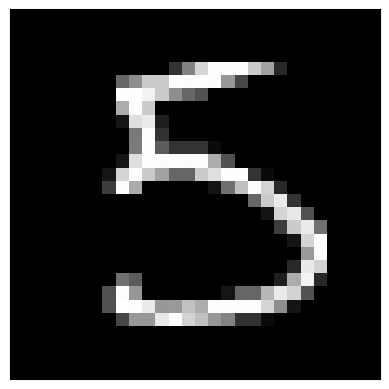

Label : 9


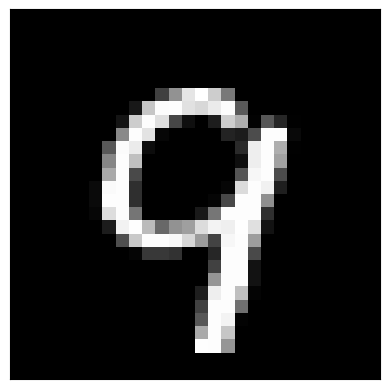

Label : 7


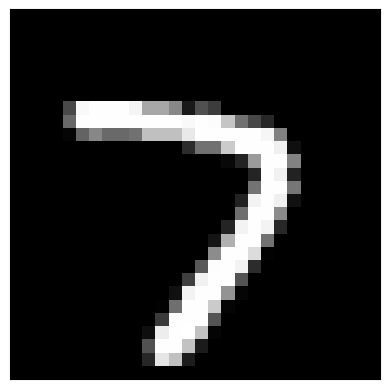

Label : 3


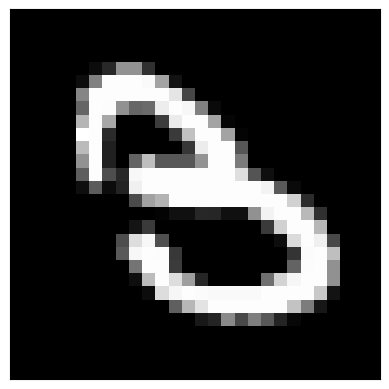

Label : 4


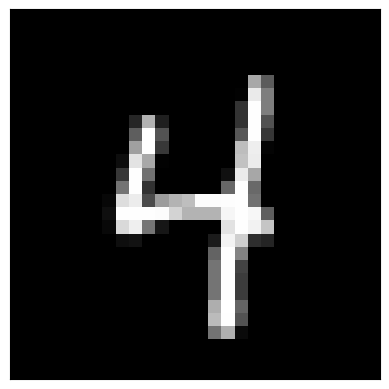

Label : 9


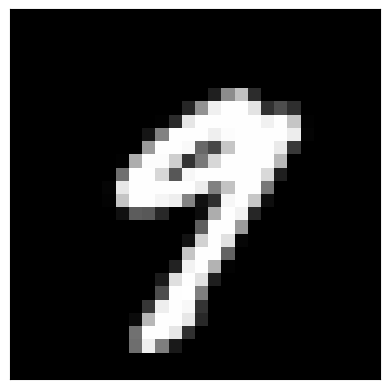

In [5]:
import matplotlib.pyplot as plt

def plot_image(input, target, i):
    print("Label :", target)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.imshow(input, cmap='gray')
    plt.savefig("MNIST-"+str(target)+"-"+str(i)+".png", bbox_inches='tight', pad_inches=0)
    plt.show()

for i, (input, target) in enumerate(val_loader):
    plot_image(input[0][0], target[0].item(), i)
    if i==20:
        break

## Model

Now we create the model.  This will have 784 inputs (corresponding to the 28x28 pixels in each image), with two dense hidden layers (128 and 32 nodes respectively), followed by a 10 node output layer.  Each output layer provides a prediction score for each true category (ie. each true digit value). A softmax function is included so the outputs can be converted to probabilistic values, however this is not used in training.  Lastly, the loss is obtained via CrossEntropyLoss() which is like binary cross-entropy, but extended for multiple categories.


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class MNISTModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )
        self.softmax = nn.Softmax(dim=0)
        self.loss = nn.CrossEntropyLoss()
        
    def forward(self, xb):
        # compute the forward pass
        xb = self.flatten(xb)
        out = self.layers(xb)
        return out

    def training_step(self, batch):
        # a training step means computing the output from a batch
        x, y = batch
        y_hat = self(x)
        # then computing the loss
        # here we use the mean absolute loss
        loss = self.loss(y_hat, y)
        return loss

    def predict_single(self, input, target):
        inputs = input.unsqueeze(0) 
        predictions = self(inputs)
        prediction = self.softmax(predictions[0])
        print("y:", target)
        print("y_hat:", prediction)

We also create a Trainer class to manage training.  This will use the Adam optimiser, and defines the fit() function.

In [7]:
import numpy as np

class Trainer():

    def __init__(self, model, n_epochs, lr, train_loader, val_loader):
        self.model = model
        self.n_epochs = n_epochs
        self.loss_train = np.zeros(n_epochs)
        self.loss_val   = np.zeros(n_epochs)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
        print(self.train_loader)
        
    def fit(self):
        for epoch in range(self.n_epochs):

            # this is the training phase
            loss_t = []
            for batch in self.train_loader:
                loss = self.model.training_step(batch)
                loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()
                loss_t.append(loss.item())
            self.loss_train[epoch] = np.array(loss_t).mean()

            # this is the validation phase
            # just calculate the loss, no updating weights !
            loss_v = []
            for batch in self.val_loader:
                loss = self.model.training_step(batch).item()
                loss_v.append(loss)
            self.loss_val[epoch] = np.array(loss_v).mean()
            
            # add some printout every few epochs
            if (epoch+1) % 2 == 0 or epoch == self.n_epochs-1:
                print("Epoch [{}], val_loss: {:.4f}".format(epoch+1, self.loss_val[epoch]))

## Training

In the next cells we create the model, test it can make a prediction (albeit with random weights), and then we train it.

In [8]:
# create the model
model = MNISTModel()


input, target = dataset2[3]
model.predict_single(input, target)

y: 0
y_hat: tensor([0.0934, 0.1047, 0.1135, 0.1356, 0.0691, 0.0936, 0.0869, 0.0984, 0.1166,
        0.0883], grad_fn=<SoftmaxBackward0>)


In [9]:

trainer = Trainer(model, 25, 0.0001, train_loader, val_loader)
trainer.fit()

Epoch [2], val_loss: 0.2609
Epoch [4], val_loss: 0.1994
Epoch [6], val_loss: 0.1622
Epoch [8], val_loss: 0.1376
Epoch [10], val_loss: 0.1207
Epoch [12], val_loss: 0.1086
Epoch [14], val_loss: 0.0999
Epoch [16], val_loss: 0.0937
Epoch [18], val_loss: 0.0893
Epoch [20], val_loss: 0.0861
Epoch [22], val_loss: 0.0833
Epoch [24], val_loss: 0.0816
Epoch [25], val_loss: 0.0809


In the next cell we plot the training and validation loss for all epochs.

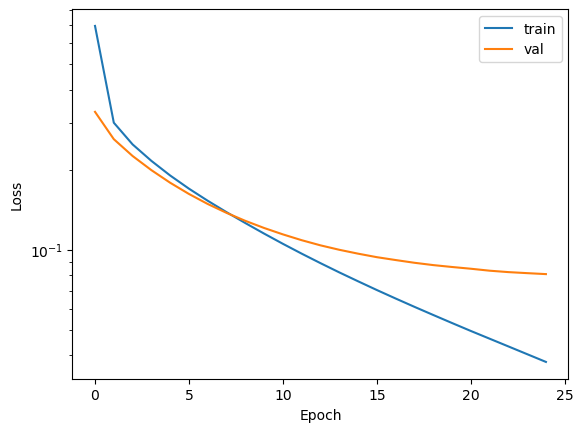

In [10]:
import matplotlib.pyplot as plt

x = np.arange(0,trainer.n_epochs)

plt.plot(x, trainer.loss_train, label="train")
plt.plot(x, trainer.loss_val, label="val")
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss.pdf")
plt.show()

## Model Performance

Next we make predictions for a few randomly selected images in the validation dataset.

y: 0
y_hat: tensor([9.9987e-01, 5.2664e-07, 3.3883e-06, 8.3743e-07, 2.0607e-08, 7.5257e-07,
        3.6080e-06, 1.1919e-04, 2.5022e-09, 1.9028e-06],
       grad_fn=<SoftmaxBackward0>)
Label : 0


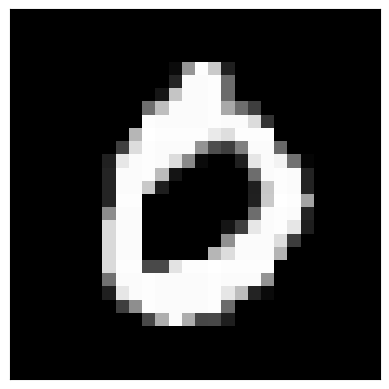

y: 9
y_hat: tensor([2.8375e-07, 5.3211e-04, 7.4576e-05, 2.6019e-04, 2.1939e-03, 9.0591e-06,
        1.2238e-08, 3.9563e-05, 1.1156e-05, 9.9688e-01],
       grad_fn=<SoftmaxBackward0>)
Label : 9


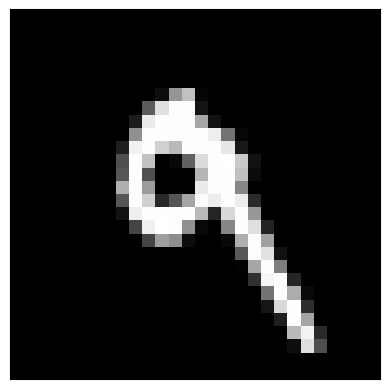

y: 5
y_hat: tensor([1.9449e-06, 4.1177e-07, 2.4070e-05, 1.4175e-06, 3.7348e-03, 9.7562e-01,
        1.9798e-02, 2.1810e-06, 8.1923e-04, 2.2974e-07],
       grad_fn=<SoftmaxBackward0>)
Label : 5


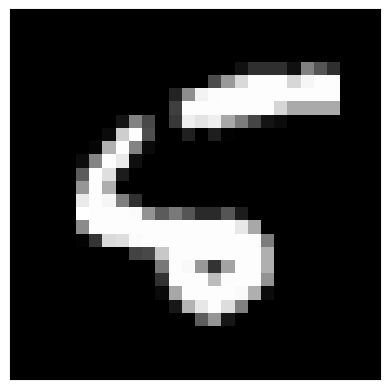

y: 1
y_hat: tensor([1.0305e-08, 9.9988e-01, 1.7262e-06, 6.9201e-05, 3.2648e-07, 7.1534e-08,
        2.4547e-07, 3.4956e-06, 4.3046e-05, 2.9415e-06],
       grad_fn=<SoftmaxBackward0>)
Label : 1


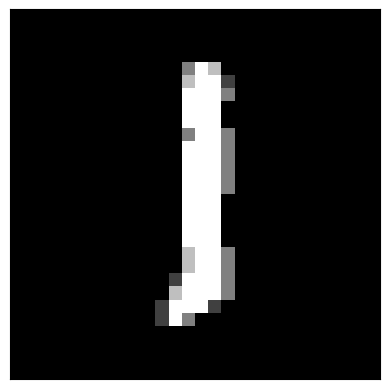

y: 5
y_hat: tensor([6.6445e-11, 6.4629e-10, 2.0932e-09, 2.9610e-06, 5.2500e-10, 1.0000e+00,
        8.1200e-08, 1.1967e-13, 5.0948e-08, 5.6146e-08],
       grad_fn=<SoftmaxBackward0>)
Label : 5


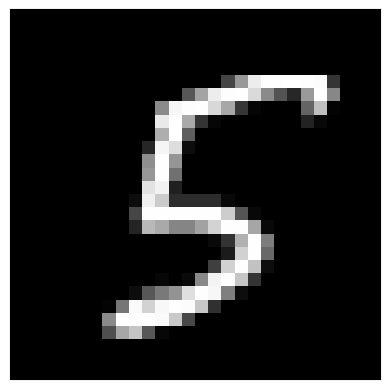

y: 2
y_hat: tensor([1.4418e-07, 2.7223e-04, 9.9972e-01, 7.5441e-06, 3.6192e-12, 1.1853e-06,
        6.7452e-09, 2.0836e-08, 1.6723e-06, 1.2525e-09],
       grad_fn=<SoftmaxBackward0>)
Label : 2


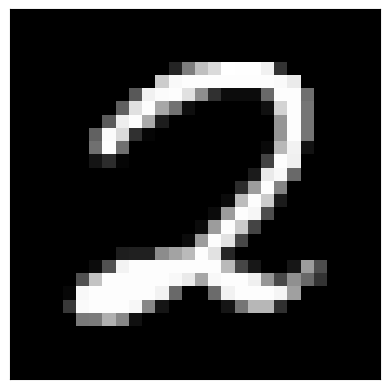

In [11]:
input, target = dataset2[3]
model.predict_single(input, target)
plot_image(input[0], target, 3)

input, target = dataset2[7]
model.predict_single(input, target)
plot_image(input[0], target, 7)

input, target = dataset2[8]
model.predict_single(input, target)
plot_image(input[0], target, 8)

input, target = dataset2[14]
model.predict_single(input, target)
plot_image(input[0], target, 14)

input, target = dataset2[23]
model.predict_single(input, target)
plot_image(input[0], target, 23)

input, target = dataset2[35]
model.predict_single(input, target)
plot_image(input[0], target, 35)

So it seems to work reasonably well on a few examples.  Now we can look at the full validation dataset and create a confusion matrix.

In [ ]:
import matplotlib.colors as colors

ys = []
y_hats = []
for batch in val_loader:
    x, y = batch
    ys.append(y.item())
    pred = np.array( model(x).detach() )
    y_hats.append(np.argmax(pred))

bins = np.linspace(-0.5, 9.5, 11)
plt.gca().set_aspect('equal')
h, xedges, yedges, img = plt.hist2d(ys, y_hats, bins=bins) #, norm=colors.LogNorm(vmin=1, vmax=1200))
print(np.max(h), np.min(h))
plt.colorbar()
plt.xlabel("True digit")
plt.ylabel("Identified digit")
plt.savefig("confusion.pdf")
plt.show()

We can also compute true positive and false positive rates

In [ ]:
n = np.sum(h)
print(n)
n_tp = np.trace(h)
print("True positive rate :", n_tp/n)

n_fp = n - n_tp
print("False positive rate :", n_fp/n)